In [9]:
import os
import qiskit
from dotenv import load_dotenv
qiskit.__version__
from qiskit_ibm_runtime import QiskitRuntimeService
load_dotenv(dotenv_path=".env")
token = os.getenv("IBM_QUANTUM_TOKEN") #retrieve token
if token is None:
    raise ValueError("IBM Quantum token is missing. Set the environment variable IBM_QUANTUM_TOKEN.")
try:
    # Try saving the account (only if it's not already saved)
    QiskitRuntimeService.save_account(channel="ibm_quantum", token=token)
    service = QiskitRuntimeService()
except Exception as e:
    if "Named account" in str(e):  # If the account already exists, just use it
        service = QiskitRuntimeService()
    else:
        raise  # Re-raise other unexpected exceptions

In [11]:
backend = service.backend(name = "ibm_brisbane")
backend.num_qubits

127

In [13]:
from qiskit import QuantumCircuit

# Create a quantum circuit with 2 qubits
qc = QuantumCircuit(2)

# Apply a Hadamard gate to qubit 0
qc.h(0)

# Apply a Hadamard gate to qubit 1
qc.h(1)

# Apply a CNOT gate (control: qubit 0, target: qubit 1)
qc.cx(0, 1)

# Draw the circuit
print(qc.draw())


     ┌───┐     
q_0: ┤ H ├──■──
     ├───┤┌─┴─┐
q_1: ┤ H ├┤ X ├
     └───┘└───┘


In [31]:
from qiskit.quantum_info import Pauli
from qiskit_aer.primitives import Estimator
estimator = Estimator()
ZZ = Pauli('ZZ')
ZI = Pauli('ZI')
IZ = Pauli('IZ')
XX = Pauli('XX')
XI = Pauli('XI')
IX = Pauli('IX')
observables = [XX, ZZ]

job = estimator.run([qc]*len(observables), observables)
result = job.result()
result

EstimatorResult(values=array([ 1.        , -0.01953125]), metadata=[{'shots': 1024, 'variance': 0.0, 'simulator_metadata': [{'num_bind_params': 1, 'runtime_parameter_bind': False, 'parallel_state_update': 12, 'parallel_shots': 1, 'sample_measure_time': 0.00204065, 'noise': 'ideal', 'batched_shots_optimization': False, 'remapped_qubits': False, 'active_input_qubits': [0, 1], 'device': 'CPU', 'time_taken': 0.002982996, 'measure_sampling': True, 'num_clbits': 2, 'max_memory_mb': 16384, 'input_qubit_map': [[1, 1], [0, 0]], 'num_qubits': 2, 'method': 'stabilizer', 'required_memory_mb': 0, 'fusion': {'enabled': False}}]}, {'shots': 1024, 'variance': 0.9996185302734375, 'simulator_metadata': [{'num_bind_params': 1, 'runtime_parameter_bind': False, 'parallel_state_update': 12, 'parallel_shots': 1, 'sample_measure_time': 0.002514784, 'noise': 'ideal', 'batched_shots_optimization': False, 'remapped_qubits': False, 'active_input_qubits': [0, 1], 'device': 'CPU', 'time_taken': 0.003410889, 'measur

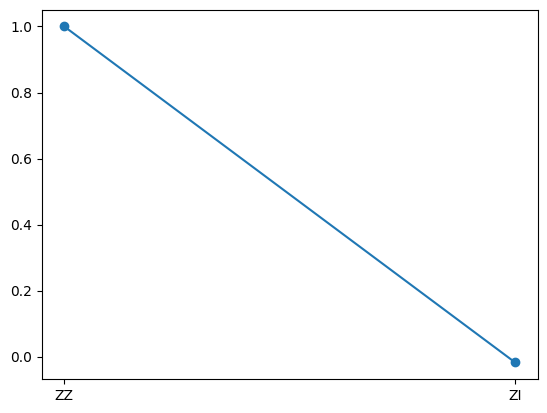

In [30]:
import matplotlib.pyplot as plt
data  = ['ZZ', 'ZI']

values = job.result().values
plt.plot(data, values , '-o')